# Word Embedding에 WEAT 적용

## 데이터 준비

In [1]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

In [2]:
import gdown

gdown.download(id="19NmxfaX7tJn6dAGvq-EM1wfw63momOq0", output="synopsis.zip", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=19NmxfaX7tJn6dAGvq-EM1wfw63momOq0
To: C:\Aiffel\AIFFEL_quest_rs\Exploration\Ex05\synopsis.zip
100%|██████████| 18.4M/18.4M [00:00<00:00, 37.1MB/s]


'synopsis.zip'

#### 데이터셋 구성

영화 구분
- synopsis_art.txt : 예술영화
- synopsis_gen.txt : 일반영화(상업영화)
- 그 외는 독립영화 등으로 분류

장르 구분
- synopsis_SF.txt: SF
- synopsis_가족.txt: 가족
- synopsis_공연.txt: 공연
- synopsis_공포(호러).txt: 공포(호러)
- synopsis_기타.txt: 기타
- synopsis_다큐멘터리.txt: 다큐멘터리
- synopsis_드라마.txt: 드라마
- synopsis_멜로로맨스.txt: 멜로로맨스
- synopsis_뮤지컬.txt: 뮤지컬
- synopsis_미스터리.txt: 미스터리
- synopsis_범죄.txt: 범죄
- synopsis_사극.txt: 사극
- synopsis_서부극(웨스턴).txt: 서부극(웨스턴)
- synopsis_성인물(에로).txt: 성인물(에로)
- synopsis_스릴러.txt: 스릴러
- synopsis_애니메이션.txt: 애니메이션
- synopsis_액션.txt: 액션
- synopsis_어드벤처.txt: 어드벤처
- synopsis_전쟁.txt: 전쟁
- synopsis_코미디.txt: 코미디
- synopsis_판타지.txt: 판타지

In [3]:
import os

data_dir = "data/synopsis"
file_name = os.path.join(data_dir, "synopsis.txt")

with open(file_name, 'r', encoding='utf-8') as file:
    for i in range(20):
        print(file.readline(), end='')

사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.
 너무 쉽게 사랑에 빠진 두 사람... 상우는 주체할 수 없을 정도로 그녀에게 빨려든다.
 그러나 겨울에 만난 두 사람의 관계는 봄을 지나 여름을 맞이하면서 삐걱거린다.
 이혼 경험이 있는 은수는 상우에게 결혼할 생각이 없다며 부담스러운 표정을 내비친다.
 "어떻게 사랑이 변하니?..."라고 묻는 상우에게 은수는 그저 "헤어져" 라고 단호하게 말한다.
 영원히 변할 것 같지 않던 사랑이 변하고, 그 사실을 받아들이지 못하는 상우는 어찌 할 바를 모른다.
 은수를 잊지 못하는 상우는 미련과 집착의 감정을 이기지 못하고 서울과 강릉을 오간다.
유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온 '애국심'이라는 성역에 일침을 가하는 다큐멘터리. 재작년 전국 민족민주 유가족협의회의 장기농성을 다룬 인상적인 다큐멘터리 <민들레>를 만들었던 독립영화집단 '빨간 눈사람'이 우리 사회 구석구석을 발빠르게 돌아다니며 애국심과 민족주의가 강요되는 현장을 발굴하여 카메라에 담았다. 박홍 서강대 명예총장, 이도형 '한국논단' 발행인, 축구해설자 신문선, 홍세화, 박노해 등 사회 각계의 '스타'들이 등장해 저마다의 확고한 신념을 성토한다. 감독 이경순과 최하동하는 이 작품을 위해 3년간 백여 명을 인터뷰했다고 한다. 2001 올해의 독립영화상 수상.
 민족과 국가란 공동체에서 부단히 권력과 부를 얻는 자, 나아가 민족과 국가란 공동체에서 얻은 신분과 부귀를 영원히 그의 자손에게 대물림하려는 자, 그래서 민족과 국가란 공동체를 부단히 유지해야만 하는 자, 따라서

## 형태소 기반 토큰화

In [4]:
from konlpy.tag import Okt

okt = Okt()
tokenized = []

with open(file_name, 'r', encoding='utf-8') as file:
    while True:
        line = file.readline()
        if not line: break
        words = okt.pos(line, stem=True, norm=True)
        res = []
        for w in words:
            if w[1] in ["Noun"]:    # "Adjective", "Verb" 등을 포함할 수도 있습니다.
                res.append(w[0])    # 명사일 때만 tokenized 에 저장하게 됩니다.
        tokenized.append(res)

In [5]:
print(len(tokenized))

71156


## Word2Vec

In [6]:
from gensim.models import Word2Vec

model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
model.wv.most_similar(positive=['영화'])

[('작품', 0.8807497620582581),
 ('다큐멘터리', 0.8496865034103394),
 ('드라마', 0.8158231973648071),
 ('영화로', 0.8067945837974548),
 ('코미디', 0.8019382953643799),
 ('주제', 0.7902320623397827),
 ('소재', 0.7707317471504211),
 ('스토리', 0.7655090093612671),
 ('형식', 0.7641764879226685),
 ('감동', 0.7585147619247437)]

In [7]:
model.wv.most_similar(positive=['사랑'])

[('행복', 0.7071424722671509),
 ('첫사랑', 0.6925069689750671),
 ('만남', 0.677944540977478),
 ('운명', 0.6774967312812805),
 ('진심', 0.6726503372192383),
 ('우정', 0.6725919246673584),
 ('토마슈', 0.6706110239028931),
 ('이별', 0.6700506210327148),
 ('연애', 0.6695327758789062),
 ('애정', 0.6645239591598511)]

In [8]:
model.wv.most_similar(positive=['연극'])

[('시나리오', 0.8961735963821411),
 ('영감', 0.8872185945510864),
 ('연기자', 0.8783904314041138),
 ('영화감독', 0.8782998919487),
 ('예술가', 0.8725840449333191),
 ('캐스팅', 0.864933431148529),
 ('배우', 0.8632190227508545),
 ('감성', 0.8608429431915283),
 ('창작', 0.8580390810966492),
 ('연기', 0.8570938110351562)]

## target, attribute 단어 셋 만들기

- target: 에술영화 / 일반영화
- attribute: 장르

In [9]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

art_txt = 'synopsis_art.txt'   # 예술영화
gen_txt = 'synopsis_gen.txt'   # 일반영화

def read_token(file_name):
    okt = Okt()
    result = []
    with open(data_dir + '/' + file_name, 'r', encoding='utf-8') as fread:
        print(file_name, '파일을 읽고 있습니다.')
        while True:
            line = fread.readline()
            if not line: break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:          # 명사만 추출
                    result.append((word[0]))
    return ' '.join(result)

In [10]:
art = read_token(art_txt)
gen = read_token(gen_txt)

synopsis_art.txt 파일을 읽고 있습니다.
synopsis_gen.txt 파일을 읽고 있습니다.


In [11]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([art, gen])

print(X.shape)
print(vectorizer.vocabulary_['영화'])
print(vectorizer.get_feature_names_out()[23976])

(2, 41082)
23976
영화


In [12]:
# 대표 단어 정렬
m1 = X[0].tocoo()   # art를 TF-IDF로 표현한 sparse matrix를 가져옵니다.
m2 = X[1].tocoo()   # gen을 TF-IDF로 표현한 sparse matrix를 가져옵니다.

w1 = [[i, j] for i, j in zip(m1.col, m1.data)]
w2 = [[i, j] for i, j in zip(m2.col, m2.data)]

w1.sort(key=lambda x: x[1], reverse=True)   #art를 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.
w2.sort(key=lambda x: x[1], reverse=True)   #gen을 구성하는 단어들을 TF-IDF가 높은 순으로 정렬합니다.

print('예술영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w1[i][0]], end=', ')

print('\n')

print('일반영화를 대표하는 단어들:')
for i in range(100):
    print(vectorizer.get_feature_names_out()[w2[i][0]], end=', ')

예술영화를 대표하는 단어들:
그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구, 남자, 가족, 이야기, 마을, 사건, 마음, 세상, 아버지, 아이, 엄마, 모든, 여자, 대한, 서로, 과연, 시간, 다시, 아들, 소녀, 아내, 다른, 영화제, 사이, 세계, 사실, 하나, 점점, 남편, 감독, 여행, 인생, 발견, 모두, 순간, 우리, 가장, 마지막, 아빠, 생활, 통해, 모습, 기억, 죽음, 비밀, 학교, 음악, 한편, 소년, 생각, 도시, 명의, 결혼, 사고, 전쟁, 위기, 때문, 이제, 최고, 이자, 과거, 일상, 경찰, 간다, 상황, 미국, 운명, 결심, 관계, 현실, 지금, 단편, 여인, 하루, 이름, 이후, 준비, 인간, 만난, 감정, 처음, 국제, 누구, 살인, 충격, 동안, 존재, 그린, 어머니, 연인, 계속, 동생, 작품, 

일반영화를 대표하는 단어들:
자신, 그녀, 영화제, 위해, 사람, 시작, 국제, 영화, 친구, 사랑, 남자, 이야기, 대한, 서울, 여자, 사건, 남편, 아이, 가족, 아버지, 다른, 마을, 시간, 엄마, 아들, 모든, 단편, 마음, 사실, 다시, 세계, 모습, 작품, 통해, 생각, 서로, 세상, 발견, 감독, 아내, 관계, 소녀, 사이, 하나, 우리, 애니메이션, 때문, 여성, 죽음, 과연, 점점, 인간, 생활, 한편, 결혼, 상황, 모두, 기억, 명의, 소년, 여행, 가장, 간다, 순간, 이제, 도시, 비밀, 학교, 과거, 가지, 이자, 경찰, 마지막, 미국, 동안, 전쟁, 주인공, 대해, 존재, 현실, 연출, 사고, 살인, 일상, 어머니, 계속, 사회, 인생, 다큐멘터리, 부문, 섹스, 최고, 바로, 의도, 동생, 하루, 위기, 계획, 정체, 한국, 

In [13]:
# 겹치지 않는 대표 단어 15개 추출
n = 15
w1_, w2_ = [], []
for i in range(100):
    w1_.append(vectorizer.get_feature_names_out()[w1[i][0]])
    w2_.append(vectorizer.get_feature_names_out()[w2[i][0]])

# w1에만 있고 w2에는 없는, 예술영화를 잘 대표하는 단어를 15개 추출한다.
target_art, target_gen = [], []
for i in range(100):
    if (w1_[i] not in w2_) and (w1_[i] in model.wv): target_art.append(w1_[i])
    if len(target_art) == n: break

# w2에만 있고 w1에는 없는, 일반영화를 잘 대표하는 단어를 15개 추출한다.
for i in range(100):
    if (w2_[i] not in w1_) and (w2_[i] in model.wv): target_gen.append(w2_[i])
    if len(target_gen) == n: break

print('예술영화를 대표하는 단어들:')
print(target_art)
print('일반영화를 대표하는 단어들:')
print(target_gen)

예술영화를 대표하는 단어들:
['아빠', '음악', '운명', '결심', '지금', '여인', '이름', '이후', '준비', '만난', '감정', '처음', '누구', '충격', '그린']
일반영화를 대표하는 단어들:
['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


### 장르별 대표 단어 추출

In [14]:
genre_txt = ['synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_action.txt', 'synopsis_comedy.txt', 'synopsis_war.txt', 'synopsis_horror.txt']
genre_name = ['드라마', '멜로로맨스', '액션', '코미디', '전쟁', '공포(호러)']

In [15]:
genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))

synopsis_drama.txt 파일을 읽고 있습니다.
synopsis_romance.txt 파일을 읽고 있습니다.
synopsis_action.txt 파일을 읽고 있습니다.
synopsis_comedy.txt 파일을 읽고 있습니다.
synopsis_war.txt 파일을 읽고 있습니다.
synopsis_horror.txt 파일을 읽고 있습니다.


In [16]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)

print(X.shape)

(6, 33151)


In [17]:
# 장르별 대표 단어 15개
m = [X[i].tocoo() for i in range(X.shape[0])]

w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]

for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)
attributes = []
for i in range(len(w)):
    print(genre_name[i], end=': ')
    attr = []
    j = 0
    while (len(attr) < 15):
        if vectorizer.get_feature_names_out()[w[i][j][0]] in model.wv:
            attr.append(vectorizer.get_feature_names_out()[w[i][j][0]])
            print(vectorizer.get_feature_names_out()[w[i][j][0]], end=', ')
        j += 1
    attributes.append(attr)
    print()

드라마: 자신, 영화제, 그녀, 사람, 사랑, 위해, 영화, 시작, 국제, 남자, 친구, 이야기, 여자, 아버지, 엄마, 
멜로로맨스: 그녀, 사랑, 자신, 시작, 남자, 남편, 여자, 사람, 친구, 위해, 마음, 섹스, 결혼, 서로, 아내, 
액션: 위해, 자신, 시작, 조직, 사건, 사람, 그녀, 경찰, 전쟁, 친구, 모든, 목숨, 사실, 세계, 가족, 
코미디: 그녀, 자신, 시작, 위해, 사랑, 사람, 친구, 영화, 남자, 여자, 영화제, 가족, 과연, 마을, 사건, 
전쟁: 전쟁, 위해, 전투, 시작, 작전, 독일군, 부대, 독일, 윈터스, 자신, 사람, 공격, 임무, 병사, 연합군, 
공포(호러): 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 남자, 가족, 영화, 하나, 


### TF-IDF 문제점

TF-IDF를 사용해 target(예술영화 / 일반영화)과 attribute(장르별) 단어 셋을 자동으로 구성하여 각 문서를 대표하는 단어를 어느 정도 잘 선별할 수 있었다.

그러나 다른 장르의 단어 셋에 단어가 **중복**된다는 문제가 있었다. 상위 단어를 보면 **'그녀, 자신, 시작, 위해, 사람'** 처럼 장르나 영화 구분과 무관하게 등장하는 단어들이 있다.

WEAT는 두 attribute set이 서로 대비되는 개념을 형성한다는 전제에서 편향을 측정한다. A와 B에 같은 단어가 잇으면 개념의 대비가 흐려져 WEAT score의 신뢰도가 떨어진다.

### 해결 방안

1. 시놉시스 줄 단위 문서 분할
- 문서가 적어서 IDF의 변별력이 약해 공통어가 상위로 올라온다.
- 각 파일을 시놉시스 단위로 나눠 문서 수를 늘리면, 모든 장르에 나오는 공통어는 df가 커져 IDF가 낮아지고 하위권으로 내려간다.

2. 불용어 제거
- 여러 장르에 등장하는 단어는 특정 개념을 대표하지 못한다.
- 전체 장르 중 일정 비율 이상에 등장하는 단어를 불용어로 지정해 제외한다.

In [18]:
def read_synopses(file_name):
    """파일을 시놉시스 단위로 묶어 리스트로 반환"""
    synopses, buf = [], []
    with open(data_dir + '/' + file_name, 'r', encoding='utf-8') as fread:
        for line in fread:
            if line.strip() == '':
                continue
            if not line[0].isspace():        # 들여쓰기 없으면 새 시놉시스 시작
                if buf:
                    synopses.append(' '.join(buf))
                buf = [line.strip()]
            else:                            # 공백으로 시작하면 이어지는 줄
                buf.append(line.strip())
        if buf:
            synopses.append(' '.join(buf))
    return synopses

In [19]:
def synopses_tokenizer(text, okt):
    """시놉시스 한 편에서 명사 추출"""
    nouns = [w[0] for w in okt.pos(text, stem=True, norm=True) if w[1] == "Noun"]
    return ' '.join(nouns)

In [20]:
# 예술영화 / 일반영화를 시놉시스 단위 문서로 나누고 토큰화
okt = Okt()

art_synopses = read_synopses(art_txt)
gen_synopses = read_synopses(gen_txt)

print('예술영화 시놉시스 수:', len(art_synopses))
print('일반영화 시놉시스 수:', len(gen_synopses))

art_docs = [synopses_tokenizer(s, okt) for s in art_synopses]
gen_docs = [synopses_tokenizer(s, okt) for s in gen_synopses]

예술영화 시놉시스 수: 3635
일반영화 시놉시스 수: 20015


In [22]:
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']
genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']

In [23]:
# 장르별 시놉시스도 같은 방식으로 토큰화
genre_docs = []
for file_name in genre_txt:
    synopses = read_synopses(file_name)
    genre_docs.append([synopses_tokenizer(s, okt) for s in synopses])
    print(f'{file_name}: {len(synopses)}')

synopsis_SF.txt: 323
synopsis_family.txt: 140
synopsis_show.txt: 155
synopsis_horror.txt: 1025
synopsis_etc.txt: 1705
synopsis_documentary.txt: 3085
synopsis_drama.txt: 7198
synopsis_romance.txt: 2001
synopsis_musical.txt: 58
synopsis_mystery.txt: 256
synopsis_crime.txt: 454
synopsis_historical.txt: 48
synopsis_western.txt: 15
synopsis_adult.txt: 891
synopsis_thriller.txt: 688
synopsis_animation.txt: 3373
synopsis_action.txt: 1845
synopsis_adventure.txt: 181
synopsis_war.txt: 122
synopsis_comedy.txt: 1644
synopsis_fantasy.txt: 233


In [56]:
# 23개 그룹을 한 코퍼스로 합쳐 TF-IDF
groups = [art_docs, gen_docs] + genre_docs
group_name = ['예술영화', '일반영화'] + genre_name

vectorizer = TfidfVectorizer(min_df=2, tokenizer=str.split, token_pattern=None)
X = vectorizer.fit_transform([d for g in groups for d in g])
feature_names = vectorizer.get_feature_names_out()

print(X.shape)

(49090, 41708)


In [57]:
# 그룹별로 문서 TF-IDF를 평균내어 그룹 대표 점수를 만든다.
scores, start = [], 0
for g in groups:
    scores.append(np.asarray(X[start:start + len(g)].mean(axis=0)).ravel())
    start += len(g)

def top_words(score, k):
    """점수 상위 k개 단어"""
    return [feature_names[i] for i in np.argsort(-score)[:k]]

In [80]:
from collections import Counter

def build_stopwords(scores, top_k=100, min_groups=5):
    """각 그룹의 상위 top_k 단어 중 min_groups개 이상 그룹에 등장하는 단어를 불용어로 지정"""
    cnt = Counter()
    for score in scores:
        cnt.update(top_words(score, top_k))
    return {w for w, c in cnt.items() if c >= min_groups}

# 영화제 관련 줄에 등장하는 단어, 의미 없는 단어를 불용어로 지정
domain_stopwords = {
    '영화제', '페스티벌', '인디애니페스트', '인디다큐페스티발', '아시아나', '미장센',
    '판타스틱', '포럼', '뉴미디어', '메트로', '부천', '전주', '부산', '서울',
    '국제', '부문', '경쟁', '초청', '수상', '상영', '상영작', '출품', '개막', '심사',
    '단편', '단편영화', '독립', '퀴어', '청소년',
    '번', '초', '관', '단', '차', '편', '점',
    '로', '존', '삭', '카', '맨', '애', '철'
}

stopwords = build_stopwords(scores, top_k=100, min_groups=13) | domain_stopwords

print('불용어 개수:', len(stopwords), f'(도메인 불용어 {len(domain_stopwords)})')
print(', '.join(sorted(stopwords)[:40]))

불용어 개수: 88 (도메인 불용어 43)
가족, 개막, 것, 경쟁, 곳, 관, 국제, 그, 그녀, 날, 남자, 뉴미디어, 다른, 단, 단편, 단편영화, 독립, 두, 딸, 로, 를, 마을, 말, 맨, 메트로, 모든, 미장센, 발견, 번, 부문, 부산, 부천, 사건, 사람, 사랑, 사실, 삭, 살, 상영, 상영작


In [81]:
# 불용어를 제외하고 target(예술영화 / 일반영화) 단어 셋 추출
n = 15
k = 300        # 불용어를 빼고도 n개를 채울 수 있도록 후보 범위를 넉넉히 잡는다.

def pick_words(score, exclude, n, stopwords):
    """불용어와 exclude를 뺀 뒤, 임베딩에 있는 상위 n개 단어"""
    result = []
    for w in top_words(score, k):
        if w in stopwords or w in exclude or w not in model.wv:
            continue
        result.append(w)
        if len(result) == n: break
    return result

w1_ = [w for w in top_words(scores[0], k) if w not in stopwords]   # 예술영화
w2_ = [w for w in top_words(scores[1], k) if w not in stopwords]   # 일반영화

target_art = pick_words(scores[0], w2_, n, stopwords)
target_gen = pick_words(scores[1], w1_, n, stopwords)

print('예술영화를 대표하는 단어들:')
print(target_art)
print('일반영화를 대표하는 단어들:')
print(target_gen)

예술영화를 대표하는 단어들:
['내용', '파리', '마주', '당신', '만남', '프랑스', '갈등', '매력', '연애', '첫사랑', '자살', '남녀', '혼란', '고백', '천재']
일반영화를 대표하는 단어들:
['애니메이션', '연출', '의도', '섹스', '다큐', '노인', '환경', '소리', '팀', '그것', '공간', '힘', '자기', '표현', '상상']


In [82]:
# 불용어를 제외하고 attribute(장르별) 단어 셋 추출
attributes = []
for i, name in enumerate(genre_name):
    attr = pick_words(scores[i + 2], set(), 15, stopwords)   # scores[0], scores[1]은 art/gen
    attributes.append(attr)
    print(name, end=': ')
    print(', '.join(attr))

SF: 지구, 인류, 인간, 우주, 미래, 우주선, 세계, 박사, 로봇, 외계, 정체, 전쟁, 존재, 공격, 행성
가족: 아빠, 제, 할머니, 학교, 소년, 소녀, 시골, 크리스마스, 동구, 엠마, 번개, 고양이, 길, 모험, 모두
공연: 오페라, 실황, 공연, 토스카, 왕자, 콘서트, 카바, 올레, 공주, 베르디, 비극, 그린, 프레, 백작, 오텔로
공포(호러): 공포, 죽음, 좀비, 악령, 살인, 저주, 밤, 정체, 소녀, 살해, 비밀, 하나, 귀신, 명의, 안
기타: 제, 지하철, 유럽, 삶, 소녀, 소년, 대한, 우리, 나, 작품, 이미지, 시간, 그린, 통해, 꿈
다큐멘터리: 제, 다큐멘터리, 다큐, 삶, 대한, 감독, 우리, 나, 여성, 세계, 통해, 환경, 한국, 기록, 작품
드라마: 제, 삶, 소녀, 남편, 대한, 마음, 서로, 시간, 소년, 어머니, 그린, 꿈, 둘, 못, 관계
멜로로맨스: 남편, 섹스, 마음, 결혼, 부부, 서로, 관계, 유혹, 코, 둘, 몸, 점점, 새엄마, 회사, 못
뮤지컬: 뮤지컬, 충무로, 음악, 최고, 제, 춤, 크리스틴, 공연, 노래, 무대, 팬텀, 소녀, 바흐, 파두, 연화
미스터리: 진실, 죽음, 기억, 미스터리, 살인, 사고, 의문, 소설, 범인, 발생, 정체, 비밀, 형사, 사이먼, 하나
범죄: 경찰, 조직, 살인, 범죄, 마약, 돈, 형사, 범인, 은행, 살해, 수사, 계획, 뒤, 복수, 작전
사극: 조선, 왕, 황제, 권력, 과, 궁, 향, 운명, 역사, 최고, 영조, 소리, 명, 청, 팔도
서부극(웨스턴): 서부, 보안관, 카우보이, 제임스, 복수, 무법자, 벌린, 헨리, 장고, 현상금, 분노, 동생, 아르, 버질, 프린트
성인물(에로): 그린, 남편, 마사지, 행각, 코, 유부녀, 관계, 섹스, 성적, 정사, 몸, 불륜, 주인공, 에피소드, 회사
스릴러: 살인, 경찰, 살해, 비밀, 범인, 점점, 형사, 진실, 사고, 충격, 정체, 남편, 죽음, 둘, 뒤
애니메이션: 애니메이션, 제, 애니, 소녀, 만

## WEAT score 구하기

In [83]:
# 장르쌍마다 WEAT 점수를 채울 행렬
matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

In [84]:
def cos_sim(i, j):
    # 벡터마다 자기 norm으로 나눠야 코사인 유사도가 된다.
    # norm(i)*norm(j)처럼 행렬 전체 norm으로 나누면 A와 B의 크기 차이가 점수에 섞인다.
    return dot(i, j.T) / (norm(i, axis=-1, keepdims=True) * norm(j, axis=-1))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B

In [85]:
def weat_score(X, Y, A, B):

    s_X = s(X, A, B)
    s_Y = s(Y, A, B)

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))

    return  (mean_X-mean_Y)/std_dev

In [86]:
# 모든 장르쌍에 대해 WEAT 계산
# TF-IDF에서 쓴 X와 이름이 겹치지 않도록 target_X / target_Y로 둔다.
target_X = np.array([model.wv[word] for word in target_art])   # 예술영화
target_Y = np.array([model.wv[word] for word in target_gen])   # 일반영화

attribute_vecs = [np.array([model.wv[word] for word in attr]) for attr in attributes]

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        score = weat_score(target_X, target_Y, attribute_vecs[i], attribute_vecs[j])
        matrix[i][j] = score
        matrix[j][i] = -score      # A와 B를 맞바꾸면 부호만 반대가 된다

In [87]:
# 장르쌍이 21C2 = 210개라 절댓값이 큰 쌍부터 확인한다.
results = []
for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        results.append((matrix[i][j], genre_name[i], genre_name[j]))

results.sort(key=lambda x: abs(x[0]), reverse=True)

print(f'전체 {len(results)}개 장르쌍')
for score, a, b in results:
    print(f'{a:>12} - {b:<12} {score:+.4f}')

전체 210개 장르쌍
          SF - 액션           -1.0836
          SF - 어드벤처         -1.0810
          SF - 서부극(웨스턴)     -1.0679
          사극 - 서부극(웨스턴)     -1.0625
          SF - 미스터리         -1.0224
         드라마 - 판타지          +1.0012
          SF - 스릴러          -1.0010
          SF - 범죄           -0.9893
      공포(호러) - 스릴러          -0.9763
    서부극(웨스턴) - 애니메이션        +0.9638
          SF - 사극           -0.9468
          공연 - 뮤지컬          +0.9201
          공연 - 애니메이션        +0.9092
          기타 - 드라마          -0.8850
         드라마 - 애니메이션        +0.8742
         스릴러 - 판타지          +0.8693
          SF - 공포(호러)       -0.8671
          SF - 드라마          -0.8548
          SF - 공연           -0.8516
          SF - 가족           -0.8402
        미스터리 - 판타지          +0.8151
          가족 - 판타지          +0.7985
       애니메이션 - 코미디          -0.7881
       다큐멘터리 - 서부극(웨스턴)     -0.7829
         코미디 - 판타지          +0.7805
       다큐멘터리 - 드라마          -0.7800
         스릴러 - 애니메이션        +0.7749
          SF - 코

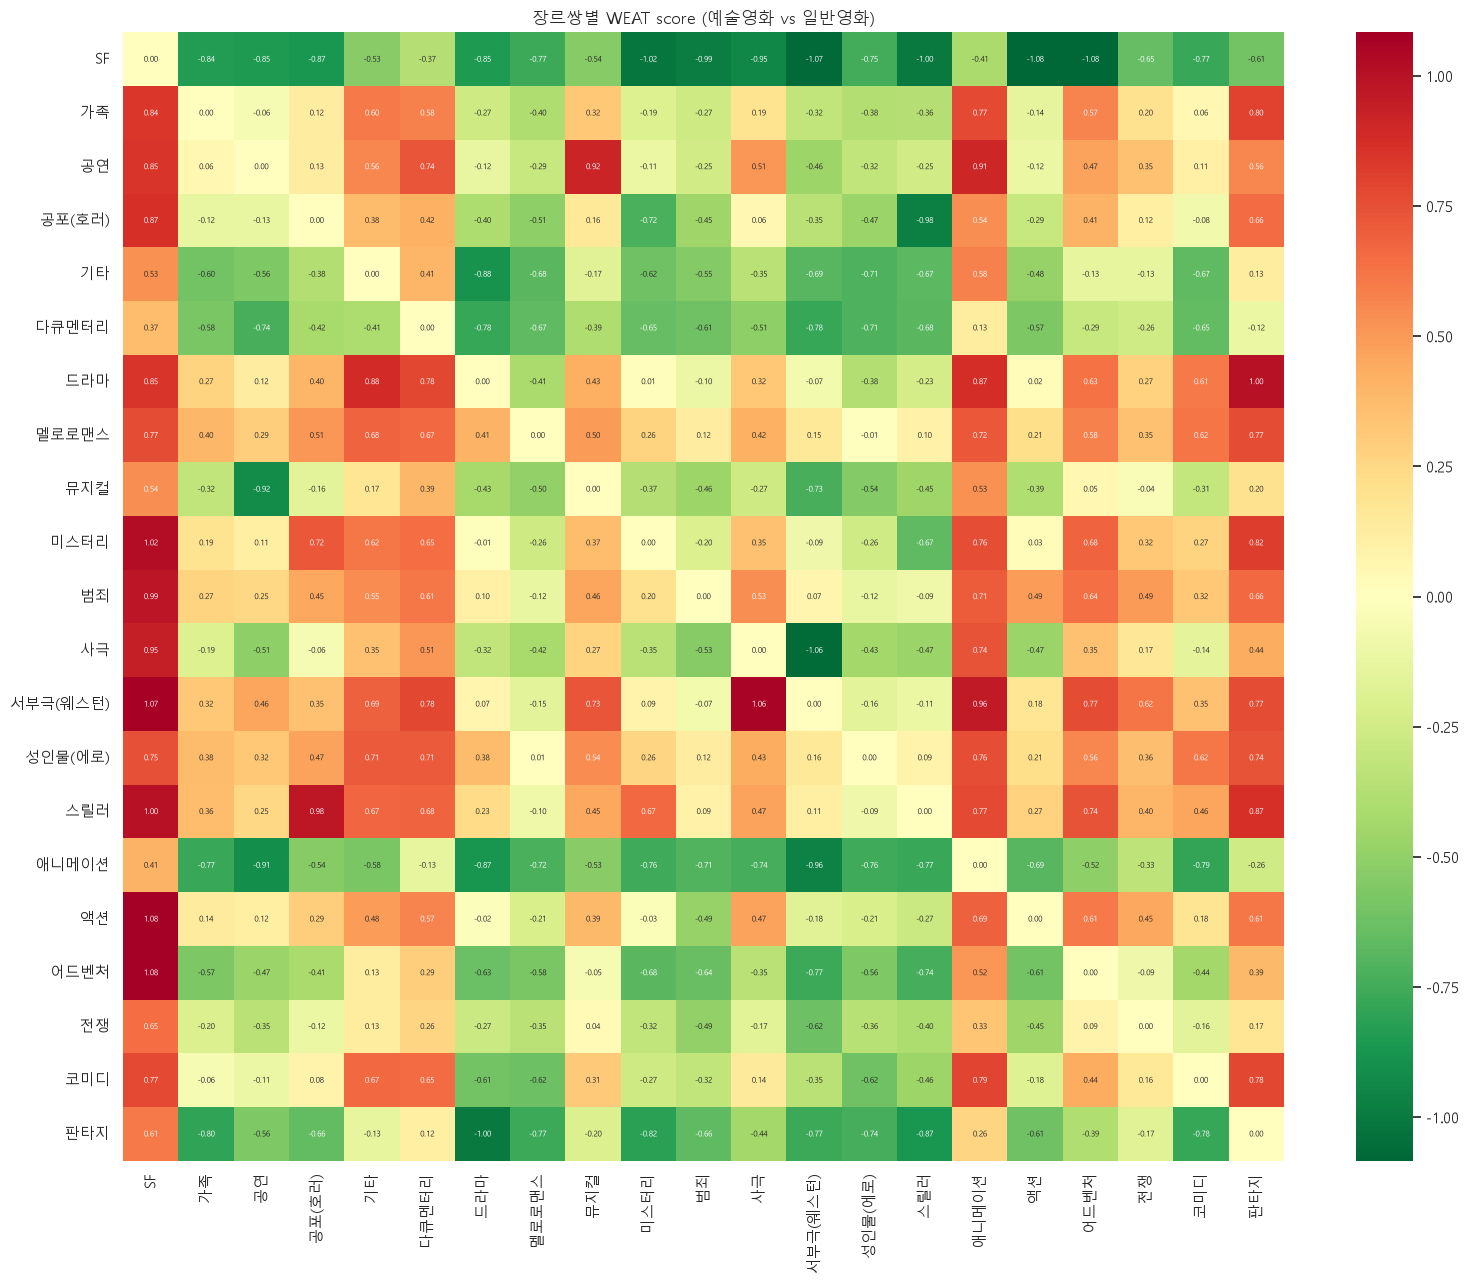

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 지원 폰트 (Windows)
sns.set(font='Malgun Gothic')

# 마이너스 부호
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(16, 13))

ax = sns.heatmap(matrix, xticklabels=genre_name, yticklabels=genre_name,
                 annot=True, fmt='.2f', annot_kws={'size': 6},
                 cmap='RdYlGn_r', center=0)
plt.title('장르쌍별 WEAT score (예술영화 vs 일반영화)')
plt.tight_layout()
plt.show()

## 결과 해석

### 부호 규약

`matrix[i][j]`는 `weat_score(예술영화, 일반영화, 장르 i, 장르 j)`이다.

- **양수**: 장르 i가 장르 j보다 **예술영화** 단어 셋에 가깝다.
- **음수**: 장르 i가 장르 j보다 **일반영화** 단어 셋에 가깝다.

한 장르의 전반적인 성향은 히트맵의 **행 평균**(그 장르와 나머지 20개 장르 점수의 평균)으로 읽을 수 있다.

| 예술영화 쪽 (행 평균 상위) | | 일반영화 쪽 (행 평균 하위) | |
|---|---|---|---|
| 스릴러 | +0.47 | SF | -0.80 |
| 서부극(웨스턴) | +0.44 | 애니메이션 | -0.60 |
| 성인물(에로) | +0.43 | 판타지 | -0.47 |
| 멜로로맨스 | +0.43 | 다큐멘터리 | -0.47 |
| 범죄 | +0.37 | 기타 | -0.33 |
| 드라마 | +0.32 | 어드벤처 | -0.26 |

### 상식에 부합하는 부분

- **SF(-0.80), 애니메이션(-0.60), 판타지(-0.47)가 일반(상업)영화 쪽 최하단**에 모였다. 큰 제작비와 CG·장르 관습에 기대는 상업영화 계열이라는 통념과 맞는다. 절댓값 상위 15쌍 중 7쌍이 SF가 낀 쌍(`SF-액션 -1.08`, `SF-어드벤처 -1.08`, `SF-서부극 -1.07`)일 만큼 SF는 축의 한쪽 끝에 확실히 자리잡았다.
- **드라마(+0.32)가 예술영화 쪽 양수**로 나왔다. 인물과 관계 중심의 서사가 예술영화 target과 가깝다는 점에서 기대와 일치한다.
- `드라마-판타지 +1.00`, `서부극-애니메이션 +0.96`처럼 **실사 인물극과 판타지·애니메이션이 대비되는 쌍**에서 값이 크게 나온 것도 일관적이다.

### 상식과 어긋나는 부분

- **다큐멘터리가 -0.47로 일반영화 쪽**이다. 예술·독립영화 쪽에 놓이리라 기대한 것과 반대다.
- **스릴러(+0.47), 성인물(+0.43), 범죄(+0.37)가 예술영화 쪽 상위**다. 전형적인 상업 장르이므로 이 역시 상식과 어긋난다.

원인은 WEAT 계산식이 아니라 **target 단어 셋**에 있다.

- 예술영화: `내용, 파리, 마주, 당신, 만남, 프랑스, 갈등, 매력, 연애, 첫사랑, 자살, 남녀, 혼란, 고백, 천재` → 유럽 배경 + 인물 감정 어휘
- 일반영화: `애니메이션, 연출, 의도, 섹스, 다큐, 노인, 환경, 소리, 팀, 그것, 공간, 힘, 자기, 표현, 상상` → 애니메이션·다큐 + 제작/형식 어휘

즉 이 축은 "예술영화 vs 일반영화"라기보다 **"실사 인물 드라마 vs 애니메이션·SF·다큐 형식"** 을 재고 있다. 그래서 인물 중심 장르(스릴러·범죄·멜로·드라마)가 한쪽에, 비실사·형식 중심 장르(SF·애니메이션·판타지·다큐)가 반대쪽에 몰렸다.

두 가지가 겹친 결과로 보인다.

1. **일반영화 그룹이 너무 이질적이다.** 일반영화는 시놉시스 20,015편(예술영화 3,635편)으로 여러 장르를 포함하는 집합이다. 이런 그룹은 문서 TF-IDF를 평균내면 분포가 평평해져 상위 단어가 특정 개념을 대표하지 못한다. 실제로 뽑힌 `그것, 자기, 표현, 공간, 힘`은 개념축이라기보다 잔여 명사에 가깝다.
2. **영화제 관련 단어를 불용어로 제거하면서 변별 신호도 함께 사라졌다.** 예술영화 시놉시스에는 영화제 수상·상영 정보가 본문에 섞여 있다. 줄거리가 아닌 메타데이터를 빼는 것 자체는 타당하지만, 사실상 예술/일반을 가르는 가장 강한 신호가 그 메타데이터다.

### 개별 장르쌍에서 읽히는 것

- **`멜로로맨스-성인물(에로) -0.0055`** — 210쌍 중 절댓값이 가장 작다. 두 attribute가 `관계, 남편, 몸, 섹스, 코, 회사` 6개를 공유해 **개념 대비가 사라지면 점수가 0으로 수렴한다**는 것을 보여주는 사례다. WEAT가 A와 B의 대조에 의존한다는 전제를 역으로 확인시켜 준다.
- **`사극-서부극(웨스턴) -1.06`** — 둘 다 과거를 배경으로 한 시대극인데 정반대 극단에 놓였다. 두 attribute 모두 특정 작품의 고유명사 비중이 높아(`영조, 팔도, 정조` / `제임스, 벌린, 헨리, 버질`) 장르 개념보다 개별 작품의 어휘가 반영된 결과로 보인다.
- `드라마-미스터리 +0.01`, `드라마-액션 +0.02`처럼 **0에 가까운 쌍**은 두 장르가 예술/일반 축에서 사실상 같은 위치라는 뜻이며, 실제로 세 장르 모두 인물·사건 중심이라는 점에서 해석과 일치한다.

### 남은 한계

- **attribute 셋 간 중복이 크다.** target 셋에는 상호 배제를 적용했지만(`exclude=w2_`) 장르 attribute는 `exclude=set()`으로 뽑아, 210개 장르쌍 중 **89쌍이 단어를 공유**한다. 특히 장르와 무관한 범용어가 여러 셋에 동시에 들어갔다 — `소녀`(7), `세계`(6), `소년`·`살인
- **표본이 적은 장르의 attribute가 고유명사로 오염되었다.** 서부극(`제임스, 벌린, 헨리, 버질, 아르, 프린트`), 뮤지컬(`크리스틴, 팬텀, 바흐, 파두, 연화`), 공연(`토스카, 카바, 올레, 베르디, 오텔로`)은 시놉시스 수가 적어 특정 작품의 등장인물·작품명이 장르 대표어로 올라온다. 그런데 절댓값 상위권에 서부극·사극·공연이 몰려 있어 큰 점수일수록 근거가 약하다.
- **형태소 분석 오류가 일부 남아 있다.** `과`(사극), `구`(액션·어드벤처), `분`(코미디), `명`(사극), `안, 앞, 못, 뒤, 둘, 향`은 조사나 의존명사가 명사로 분석된 것으로, 개념을 대표하지 못한다.

### 다음에 시도해볼 것

1. `pick_words`의 `exclude`에 다른 장르의 상위 단어를 넘겨 **attribute 셋끼리도 중복을 제거**한다. 89쌍의 중복이 줄면 특히 인접 장르(범죄–액션–스릴러–미스터리) 점수의 해석이 명확해진다.
2. `build_stopwords`의 기준을 조여 `제, 소녀, 소년, 세계, 대한` 같은 범용어를 걸러낸다.
3. 시놉시스 수가 적은 장르는 결과에서 제외한다.

### 잘 된 부분

- **시놉시스 단위 문서 분할**이 의도대로 작동했다. 문서를 파일 단위 2개에서 49,090개로 늘리자 IDF 변별력이 살아나, `SF: 지구, 인류, 우주, 로봇, 외계, 행성`, `전쟁: 전투, 독일군, 작전, 세계대전, 나치`, `범죄: 경찰, 조직, 마약, 형사, 수사`처럼 **장르 개념을 실제로 대표하는 attribute**를 얻었다. target 축의 한계와 별개로, 장르 단어 셋 자체는 대체로 상식에 부합한다.
- 21개 장르 전체 210쌍을 계산하고 히트맵과 절댓값 정렬 목록으로 함께 제시해, 개별 쌍과 장르별 경향을 모두 확인할 수 있다.